Library Needed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import KMeans
import kagglehub

Path to Download the dataset directly in Jupiter Notebook

In [2]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

Print the Path, just to confirm that the path

In [3]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\umair\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


Read the Dataset to know what are we dealing with
1- give instruction to read the document
2-give an sample of the document

In [4]:
#1
df = pd.read_csv(r'C:\Users\umair\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1\Housing.csv')
#2
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Get a full report about your dataset structure

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Get a quick overview of your dataset numeric columns only

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Give instruction the new chart window that’s 12 inches wide and 6 inches tall

In [7]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Remove outliers beyond 1st and 99th percentile (the Cleaning of Dataset)
1-identifies the lower threshold for what you consider "reasonable" prices.
2-price_lower and price_upper define the central 98% of data, ignoring extreme low/high prices.
3-finds the 1st percentile of house sizes — very small houses will be below this.
4-99th percentile for house area, very large houses above this value are considered outliers.
5-creates a cleaned dataset df_clean that excludes extreme outliers in both price and area.
6-display the size of the original and cleaned datasets
7-Shows how many rows remain after removing outliers.

In [8]:
#1
price_lower = df['price'].quantile(0.01)
#2
price_upper = df['price'].quantile(0.99)
#3
area_lower = df['area'].quantile(0.01)
#4
area_upper = df['area'].quantile(0.99)
#5
df_clean = df[(df['price'] >= price_lower) & (df['price'] <= price_upper) &
              (df['area'] >= area_lower) & (df['area'] <= area_upper)]
#6
print(f"Original dataset size: {df.shape[0]}")
#7
print(f"Cleaned dataset size: {df_clean.shape[0]}")

Original dataset size: 545
Cleaned dataset size: 521


Check the first 5 rows to confirm
show your cleaned DataFrame and shows the first 5 rows by default.

In [9]:
df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished
11,9681000,6000,4,3,2,yes,yes,yes,yes,no,2,no,semi-furnished
12,9310000,6550,4,2,2,yes,no,no,no,yes,1,yes,semi-furnished


Boxplot for House Area
1)- want to draw in the second spot of a 1×2 layout
2)- creates a vertical boxplot for the column area, showing how house sizes are distributed
3)- helps make your chart readable and descriptive

Text(0.5, 1.0, 'Boxplot of House Area')

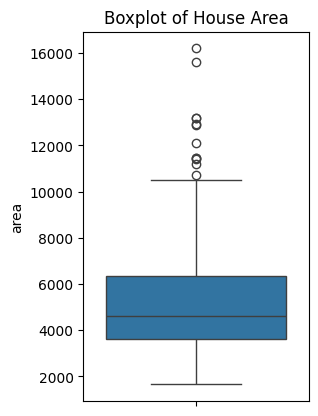

In [10]:
#1
plt.subplot(1,2,2)
#2
sns.boxplot(y=df['area'])
#3
plt.title('Boxplot of House Area')

Plot histogram of price
1-creates a new figure and sets the size of the figure: 8 inches wide × 5 inches tall.
2-makes it easier to see trends, like skewness or peaks.
3-adds a title above the plot so viewers know what it represents.
4-displays the plot on the screen.

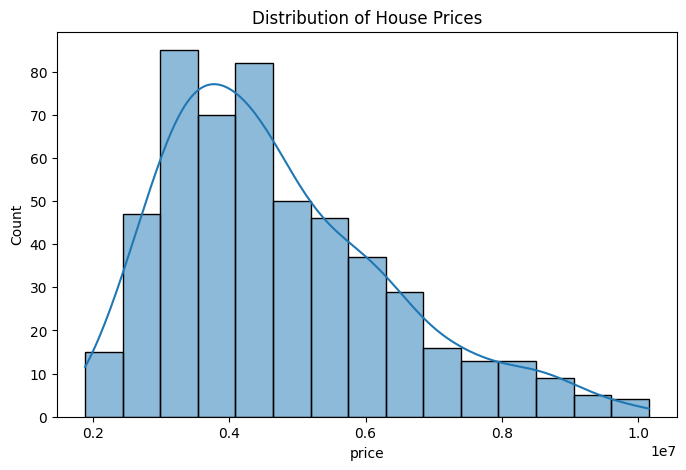

In [11]:
#1
plt.figure(figsize=(8,5))
#2
sns.histplot(df_clean['price'], kde=True)
#3
plt.title("Distribution of House Prices")
#4
plt.show()

In [12]:
print("Skewness of price:", df_clean['price'].skew())

Skewness of price: 0.8642302587876103


1-Select only numeric columns
2-Compute correlation matrix
3-Plot heatmap

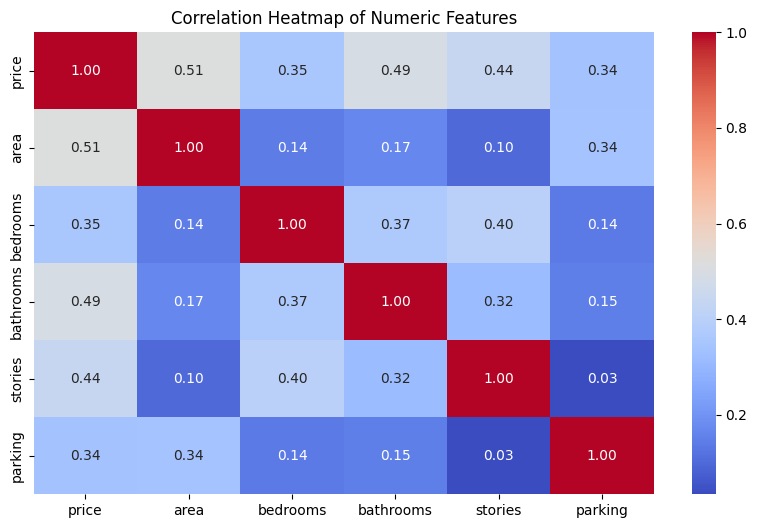

In [13]:
#1
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])

#2
corr = numeric_df.corr()

#3
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

column names from the dataset will be used as inputs (X) to predict the target variable

In [14]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Training the Model
1- exclude target 'price'
2- use 'price_log' if you decide to model log-transformed target
3- split dataset: 80% train, 20% test
4- Confirms your dataset is split correctly and Useful for understanding if you have enough data for training and testing


X → variable that stores the input features for the model
df_clean[...] → selects specific columns from your cleaned DataFrame
Example:-x = area df_clean = house size

"y = df_clean['price']"
y = the target variable (what we want the model to predict)
df_clean['price'] = selects the price column

train_test_split = function from scikit-learn that splits data into training and testing sets
test_size=0.2 → 20% of the data goes to the test set, 80% to the training set
random_state=42 = ensures reproducibility; the same split occurs every time you run the code
Example:- X_train = features for training

X_train.shape[0] = number of rows (samples) in the training set
X_test.shape[0] = number of rows in the test set
Confirms your dataset is split correctly
Useful for understanding if you have enough data for training and testing

In [15]:
#1
X = df_clean[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
#2
y = df_clean['price']
#3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#4
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 416 samples
Test set size: 105 samples


Train Decision Tree model:

1-creates a decision tree regression model
2-predictions to compare with the actual house prices
3-R² Score (r2_score) Measures how well the model explains the variance in the data
perfect prediction, 0 = model does no better than the mean.
MAE (mean_absolute_error)
-Average absolute difference between predicted and actual prices
-Gives an intuitive idea of “average prediction error.”
MSE (mean_squared_error)
-Average squared difference between predicted and actual prices
-Penalizes large errors more than MAE
RMSE (np.sqrt(mse_dt))
-Square root of MSE, expressed in the same units as the target variable
Easier to interpret than MSE
4-Prints all evaluation metrics in a readable format

In [16]:
#1
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

#2
y_pred_dt = dt.predict(X_test)

#3
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

#4
print("Decision Tree Performance:")
print(f"R2 Score: {r2_dt:.3f}")
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")

Decision Tree Performance:
R2 Score: 0.211
MAE: 1306188.44
MSE: 2755117755454.81
RMSE: 1659854.74


Train Linear Regression model

1-creates a linear regression model
2- Predict using trained Linear Regression model:
lr.predict(X_test) = uses the trained linear regression model to predict house prices for the test set
y_pred_lr = stores the predicted prices
3-Evaluate model performance
4-Prints all evaluation metrics in a readable format


In [17]:
#1
lr = LinearRegression()
lr.fit(X_train, y_train)

#2
y_pred_lr = lr.predict(X_test)

#3
r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

#4
print("Linear Regression Performance:")
print(f"R2 Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

Linear Regression Performance:
R2 Score: 0.632
MAE: 867566.78
MSE: 1284345940244.73
RMSE: 1133289.87


Train Decision Tree Regressor:

1-DecisionTreeRegressor() = creates a decision tree regression model. Predicts continuous values (house prices) by splitting the data into branches based on feature thresholds,
random_state=42 = ensures reproducibility; the tree will be the same each time you run the script.
2-The model learns rules like “if area > 1500 and bedrooms > 3 , predict price = X” to fit the training data.
3-Make predictions
4-Evaluate model performance
5-Print result

In [18]:
#1
dt = DecisionTreeRegressor(random_state=42)

#2
dt.fit(X_train, y_train)

#3
y_pred_dt = dt.predict(X_test)

#4
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

#5
print("Decision Tree Performance:")
print(f"R2 Score: {r2_dt:.3f}")
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")

Decision Tree Performance:
R2 Score: 0.211
MAE: 1306188.44
MSE: 2755117755454.81
RMSE: 1659854.74


Train Random Forest Regressor

1-RandomForestRegressor() = creates a Random Forest regression model.
Random Forest is an ensemble of decision trees; it averages the predictions of many trees to improve accuracy and reduce overfitting.
n_estimators=100 = the forest will have 100 decision trees.
random_state=42 = ensures the results are reproducible.
2-Train the modelX_train = input features (area, bedrooms, bathrooms, stories, parking), y_train = target (house prices)
3-You can now compare predictions (y_pred_rf) with actual prices (y_test) to measure accuracy.
4-Evaluate performance
5-Print performance metrics

In [19]:
#1
rf = RandomForestRegressor(n_estimators=100, random_state=42)

#2
rf.fit(X_train, y_train)

#3
y_pred_rf = rf.predict(X_test)

#4
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

#5
print("Random Forest Performance:")
print(f"R2 Score: {r2_rf:.3f}")
print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")

Random Forest Performance:
R2 Score: 0.546
MAE: 963922.98
MSE: 1586977553266.34
RMSE: 1259752.97


1-Sets up a Matplotlib figure (plotting canvas).
figsize=(8,6) = 8 inches wide, 6 inches tall.
2-sns.scatterplot() = Seaborn function to plot points.
x=y_test = actual house prices on the x-axis.
y=y_pred_rf = predicted prices on the y-axis.
Each point represents one house: its true price vs predicted price.
If predictions are perfect, all points would lie on a straight line.
3-Adds x-axis and y-axis labels and a plot title for clarity.
4-Add reference line
5-Displays the figure on the screen.

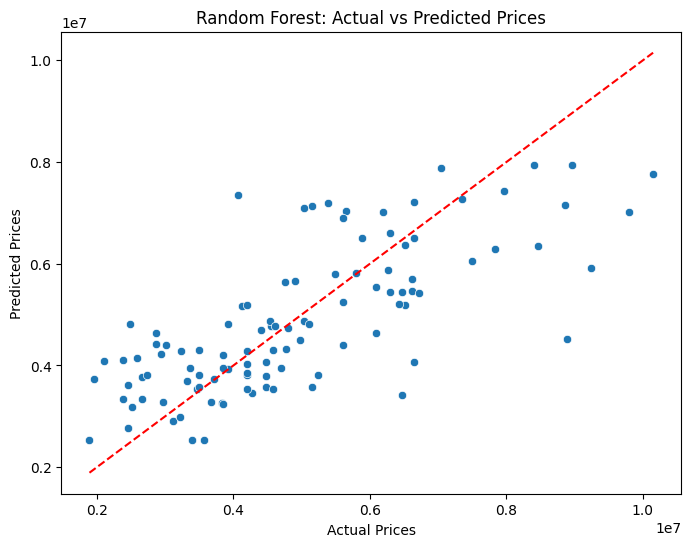

In [20]:
#1
plt.figure(figsize=(8,6))
#2
sns.scatterplot(x=y_test, y=y_pred_rf)
#3
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted Prices")
#4
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
#5
plt.show()

 1-Example new house
 2- Convert to DataFrame

In [21]:
#1
new_house = {
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'parking': [1]
}

#2
new_house_df = pd.DataFrame(new_house)

Use trained Random Forest to predict

In [22]:
predicted_price = rf.predict(new_house_df)
print(f"Predicted Price for the new house: {predicted_price[0]:,.2f}")

Predicted Price for the new house: 5,731,880.00

1-Create new data for prediction
2-Predict prices using the trained Random Forest

In [23]:
#1
new_houses = pd.DataFrame({
    'area': [4000, 7000],
    'bedrooms': [3, 5],
    'bathrooms': [2, 3],
    'stories': [1, 3],
    'parking': [1, 2]
})

#2
predicted_prices = rf.predict(new_houses)
print("Predicted Prices:", predicted_prices)

Predicted Prices: [5125330.  7991236.4]


1- Assume df_clean is your cleaned dataset
2- Split dataset
3- Initialize Random Forest
4- Hyperparameter tuning
5- Fit GridSearchCV
6- Best tuned model
7- Predict on test set
8- Evaluate performance
9-  Predict new house prices
10-Prints both model performance and predicted prices

In [24]:
#1
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X = df_clean[features]
y = df_clean['price']

#2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#3
rf = RandomForestRegressor(random_state=42)

#4
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)

#5
grid_search.fit(X_train, y_train)

#6
best_rf = grid_search.best_estimator_

#7
y_pred_test = best_rf.predict(X_test)

#8
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("Random Forest Performance (Tuned):")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R2 Score: {r2:.3f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

#9
new_houses = pd.DataFrame({
    'area': [4000, 7000],
    'bedrooms': [3, 5],
    'bathrooms': [2, 3],
    'stories': [1, 3],
    'parking': [1, 2]
})

#10
predicted_prices = best_rf.predict(new_houses)
print("Predicted Prices for New Houses:", predicted_prices)



#Interpretation: Larger houses with more bedrooms, bathrooms, stories, and parking are predicted to have higher prices, as expected.

Random Forest Performance (Tuned):
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
R2 Score: 0.642
MAE: 834855.47
MSE: 1248478611326.78
RMSE: 1117353.40
Predicted Prices for New Houses: [4731342.38770787 8008181.13545995]


Bonus:

Small Calculator to help predict the housing price
1- Helper functions for safe input
2- Interactive house price calculator
3-Create DataFrame for the input
4- Predict price using the tuned Random Forest
5- Call the function



In [26]:
#1
def get_float(prompt):
    while True:
        try:
            value = float(input(prompt))
            if value <= 0:
                print("Please enter a positive number.")
            else:
                return value
        except ValueError:
            print("Invalid input. Enter a numeric value.")

def get_int(prompt):
    while True:
        try:
            value = int(input(prompt))
            if value < 0:
                print("Please enter a non-negative integer.")
            else:
                return value
        except ValueError:
            print("Invalid input. Enter an integer.")

#2
def predict_new_house():
    print("\nCan you please give me the details of the house to predict its price:")
    area = get_float("Area (in sqft): ")
    bedrooms = get_int("Number of bedrooms: ")
    bathrooms = get_int("Number of bathrooms: ")
    stories = get_int("Number of stories: ")
    parking = get_int("Number of parking spaces: ")

    #3
    new_house = pd.DataFrame({
        'area': [area],
        'bedrooms': [bedrooms],
        'bathrooms': [bathrooms],
        'stories': [stories],
        'parking': [parking]
    })

    #4
    predicted_price = best_rf.predict(new_house)
    print(f"\nPredicted Price for this house: {predicted_price[0]:,.2f}")

#5
predict_new_house()



Can you please give me the details of the house to predict its price:

Predicted Price for this house: 3,939,222.23


Problem and Solution

1-Was asking me to download the library many time, then i was 